In [ ]:
# Predict whether a used car is a Good Buy based on its characteristics.
import pandas as pd

data = {
    "Fuel": [
        "Petrol", "Diesel", "Petrol", "Electric", "Diesel",
        "Petrol", "Electric", "Diesel", "Petrol", "Electric"
    ],

    "Transmission": [
        "Manual", "Manual", "Automatic", "Automatic", "Manual",
        "Automatic", "Automatic", "Manual", "Manual", "Automatic"
    ],

    "Age": [
        "New", "Old", "New", "New", "Old",
        "Old", "New", "Old", "New", "New"
    ],

    "Mileage": [
        "Low", "High", "Low", "Low", "High",
        "High", "Low", "High", "Low", "Low"
    ],

    "Condition": [
        "Excellent", "Good", "Excellent", "Excellent", "Good",
        "Poor", "Excellent", "Good", "Good", "Excellent"
    ],

    "GoodBuy": [
        "Yes", "No", "Yes", "Yes", "No",
        "No", "Yes", "No", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)

print(df)

       Fuel Transmission  Age Mileage  Condition GoodBuy
0    Petrol       Manual  New     Low  Excellent     Yes
1    Diesel       Manual  Old    High       Good      No
2    Petrol    Automatic  New     Low  Excellent     Yes
3  Electric    Automatic  New     Low  Excellent     Yes
4    Diesel       Manual  Old    High       Good      No
5    Petrol    Automatic  Old    High       Poor      No
6  Electric    Automatic  New     Low  Excellent     Yes
7    Diesel       Manual  Old    High       Good      No
8    Petrol       Manual  New     Low       Good     Yes
9  Electric    Automatic  New     Low  Excellent     Yes


In [ ]:
df.shape

(10, 6)

In [ ]:
df.columns

Index(['Fuel', 'Transmission', 'Age', 'Mileage', 'Condition', 'GoodBuy'], dtype='object')

In [ ]:
df.describe()

,Fuel,Transmission,Age,Mileage,Condition,GoodBuy
count,10,10,10,10,10,10
unique,3,2,2,2,3,2
top,Petrol,Manual,New,Low,Excellent,Yes
freq,4,5,6,6,5,6


In [ ]:
df.isnull().sum()

,0
Fuel,0
Transmission,0
Age,0
Mileage,0
Condition,0
GoodBuy,0


In [ ]:
training_data = df.to_dict("records")

In [ ]:
attributes = [
    "Fuel",
    "Transmission",
    "Age",
    "Mileage",
    "Condition"
]

S = {attr: "0" for attr in attributes}
G = {attr: "?" for attr in attributes}

print("Initial Specific Boundary (S):")
print(S)

print("\nInitial General Boundary (G):")
print(G)

Initial Specific Boundary (S):
{'Fuel': '0', 'Transmission': '0', 'Age': '0', 'Mileage': '0', 'Condition': '0'}

Initial General Boundary (G):
{'Fuel': '?', 'Transmission': '?', 'Age': '?', 'Mileage': '?', 'Condition': '?'}


In [ ]:
def covers(hypothesis, example, attributes):
    for attr in attributes:
        if hypothesis[attr] != "?" and hypothesis[attr] != example[attr]:
            return False
    return True

In [ ]:
def generalize_s(S, example, attributes):

    new_S = S.copy()

    for attr in attributes:

        if new_S[attr] == "0":
            new_S[attr] = example[attr]

        elif new_S[attr] != example[attr]:
            new_S[attr] = "?"

    return new_S

In [ ]:
def specialize_g(G, example, attributes, domains):

    specializations = []

    for attr in attributes:

        if G[attr] == "?":

            for value in domains[attr]:

                if value != example[attr]:

                    new_G = G.copy()
                    new_G[attr] = value
                    specializations.append(new_G)

    return specializations

In [ ]:
domains = {}

for attr in attributes:
    domains[attr] = df[attr].unique().tolist()

print(domains)

{'Fuel': ['Petrol', 'Diesel', 'Electric'], 'Transmission': ['Manual', 'Automatic'], 'Age': ['New', 'Old'], 'Mileage': ['Low', 'High'], 'Condition': ['Excellent', 'Good', 'Poor']}


In [ ]:
S = {attr: "0" for attr in attributes}
G = {attr: "?" for attr in attributes}

for i, example in enumerate(training_data, start=1):

    label = example["GoodBuy"]

    print(f"\nExample {i}: {example}")

    if label == "Yes":

        # Generalize S
        S = generalize_s(S, example, attributes)

        print("Positive example")

    else:

        # Negative example
        print("Negative example")

        # Specialize G
        specialized = specialize_g(
            G,
            example,
            attributes,
            domains
        )

        # Keep only hypotheses that do not cover negative example
        G_candidates = []

        for h in specialized:

            if not covers(h, example, attributes):
                G_candidates.append(h)

        if G_candidates:
            G = G_candidates[0]

    print("S:", S)
    print("G:", G)


Example 1: {'Fuel': 'Petrol', 'Transmission': 'Manual', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent', 'GoodBuy': 'Yes'}
Positive example
S: {'Fuel': 'Petrol', 'Transmission': 'Manual', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
G: {'Fuel': '?', 'Transmission': '?', 'Age': '?', 'Mileage': '?', 'Condition': '?'}

Example 2: {'Fuel': 'Diesel', 'Transmission': 'Manual', 'Age': 'Old', 'Mileage': 'High', 'Condition': 'Good', 'GoodBuy': 'No'}
Negative example
S: {'Fuel': 'Petrol', 'Transmission': 'Manual', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
G: {'Fuel': 'Petrol', 'Transmission': '?', 'Age': '?', 'Mileage': '?', 'Condition': '?'}

Example 3: {'Fuel': 'Petrol', 'Transmission': 'Automatic', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent', 'GoodBuy': 'Yes'}
Positive example
S: {'Fuel': 'Petrol', 'Transmission': '?', 'Age': 'New', 'Mileage': 'Low', 'Condition': 'Excellent'}
G: {'Fuel': 'Petrol', 'Transmission': '?', 'Age': '?', 'Mileage': 

In [ ]:
attributes = ["Fuel", "Transmission", "Age", "Mileage", "Condition"]

# All possible values for each attribute
domains = {
    attr: df[attr].unique().tolist()
    for attr in attributes
}

# Initial boundaries
S = {
    ("0", "0", "0", "0", "0")
}

G = {
    ("?", "?", "?", "?", "?")
}

print("Initial S:", S)
print("Initial G:", G)

Initial S: {('0', '0', '0', '0', '0')}
Initial G: {('?', '?', '?', '?', '?')}


In [ ]:
def covers(h, example):
    for i, attr in enumerate(attributes):
        if h[i] != "?" and h[i] != example[attr]:
            return False
    return True

In [ ]:
def generalize_s(h, example):

    new_h = list(h)

    for i, attr in enumerate(attributes):

        if new_h[i] == "0":
            new_h[i] = example[attr]

        elif new_h[i] != example[attr]:
            new_h[i] = "?"

    return tuple(new_h)

In [ ]:
def specialize_g(h, example):

    specializations = []

    for i, attr in enumerate(attributes):

        if h[i] == "?":

            for value in domains[attr]:

                if value != example[attr]:

                    new_h = list(h)
                    new_h[i] = value

                    specializations.append(tuple(new_h))

    return specializations

In [ ]:
for i, example in enumerate(training_data, start=1):

    label = example["GoodBuy"]

    if label == "Yes":

        # Generalize S
        new_S = set()

        for s in S:
            generalized = generalize_s(s, example)

            # Keep only if covered by at least one G
            for g in G:
                if covers(g, example):
                    new_S.add(generalized)
                    break

        S = new_S

        # Remove G hypotheses that don't cover positive example
        G = {
            g for g in G
            if covers(g, example)
        }

    else:

        # Remove S hypotheses that cover negative example
        S = {
            s for s in S
            if not covers(s, example)
        }

        # Specialize G
        new_G = set()

        for g in G:

            if covers(g, example):

                specializations = specialize_g(g, example)

                for h in specializations:

                    # Keep if it is more general than some S
                    if any(
                        all(
                            s[j] == "0" or
                            s[j] == h[j] or
                            h[j] == "?"
                            for j in range(len(attributes))
                        )
                        for s in S
                    ):
                        new_G.add(h)

            else:
                new_G.add(g)

        G = new_G

    print(f"\nExample {i} ({label})")
    print("S =", S)
    print("G =", G)


Example 1 (Yes)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 2 (No)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 3 (Yes)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 4 (Yes)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 5 (No)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 6 (No)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 7 (Yes)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 8 (No)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'Low', '?'), ('?', '?', 'New', '?', '?')}

Example 9 (Yes)
S = {('?', '?', 'New', 'Low', '?')}
G = {('?', '?', '?', 'L

In [ ]:
print("\n==============================")
print("FINAL CANDIDATE-ELIMINATION")
print("==============================")

print("\nMost Specific Boundary (S):")
for h in S:
    print(h)

print("\nMost General Boundary (G):")
for h in G:
    print(h)


FINAL CANDIDATE-ELIMINATION

Most Specific Boundary (S):
('?', '?', 'New', 'Low', '?')

Most General Boundary (G):
('?', '?', '?', 'Low', '?')
('?', '?', 'New', '?', '?')


In [ ]:
print("\n==============================")
print("FINAL VERSION SPACE")
print("==============================")

version_space = set()

for g in G:
    version_space.add(g)

version_space.add(next(iter(S)))

print("\nHypotheses in Version Space:")

for i, h in enumerate(version_space, start=1):
    print(f"H{i} = {h}")


FINAL VERSION SPACE

Hypotheses in Version Space:
H1 = ('?', '?', '?', 'Low', '?')
H2 = ('?', '?', 'New', '?', '?')
H3 = ('?', '?', 'New', 'Low', '?')


In [ ]:
print("\nMost Specific Hypothesis:")
print(next(iter(S)))

print("\nMost General Hypotheses:")
for h in G:
    print(h)


Most Specific Hypothesis:
('?', '?', 'New', 'Low', '?')

Most General Hypotheses:
('?', '?', '?', 'Low', '?')
('?', '?', 'New', '?', '?')


In [ ]:
history_ce = []

S = {
    ("0", "0", "0", "0", "0")
}

G = {
    ("?", "?", "?", "?", "?")
}

for i, example in enumerate(training_data, start=1):

    label = example["GoodBuy"]

    if label == "Yes":

        # Generalize S
        new_S = set()

        for s in S:
            generalized = generalize_s(s, example)

            if any(covers(g, example) for g in G):
                new_S.add(generalized)

        S = new_S

        # Remove G hypotheses that don't cover positive example
        G = {
            g for g in G
            if covers(g, example)
        }

    else:

        # Remove S hypotheses covering negative example
        S = {
            s for s in S
            if not covers(s, example)
        }

        # Specialize G
        new_G = set()

        for g in G:

            if covers(g, example):

                specializations = specialize_g(g, example)

                for h in specializations:

                    if any(
                        all(
                            s[j] == "0" or
                            s[j] == h[j] or
                            h[j] == "?"
                            for j in range(len(attributes))
                        )
                        for s in S
                    ):
                        new_G.add(h)

            else:
                new_G.add(g)

        G = new_G

    history_ce.append({
        "step": i,
        "label": label,
        "S": S.copy(),
        "G": G.copy()
    })

In [ ]:
import itertools

values = []

for attr in attributes:
    values.append(domains[attr] + ["?"])

all_hypotheses = list(itertools.product(*values))

print("Total possible hypotheses:", len(all_hypotheses))

Total possible hypotheses: 432


In [ ]:
version_space_sizes = []

for h in history_ce:

    consistent_count = 0

    for hypothesis in all_hypotheses:

        valid = True

        for example in training_data[:h["step"]]:

            prediction = covers(hypothesis, example)

            actual = example["GoodBuy"] == "Yes"

            if prediction != actual:
                valid = False
                break

        if valid:
            consistent_count += 1

    version_space_sizes.append(consistent_count)

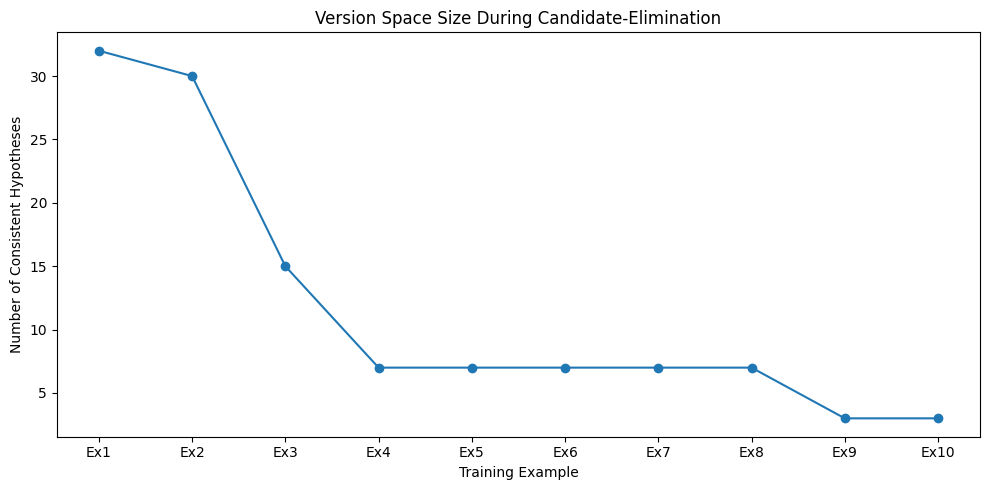

In [ ]:
# Create step labels
steps = [f"Ex{h['step']}" for h in history_ce]

# Plot version space size
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    version_space_sizes,
    marker="o"
)

plt.xlabel("Training Example")
plt.ylabel("Number of Consistent Hypotheses")
plt.title("Version Space Size During Candidate-Elimination")

plt.tight_layout()
plt.show()

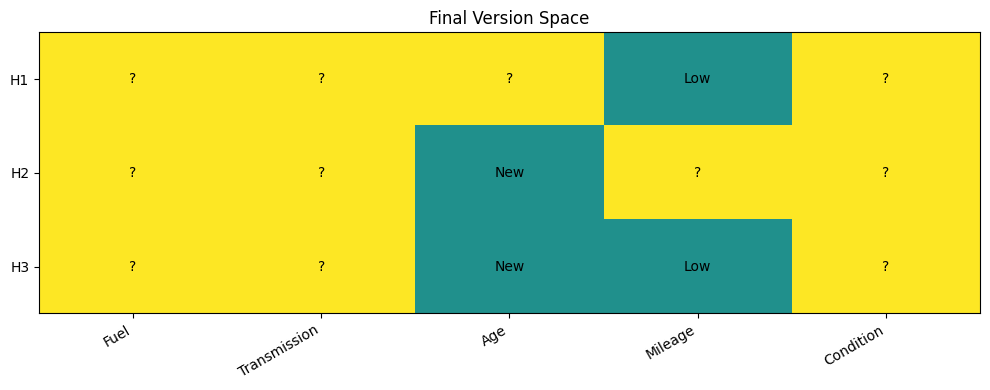

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

final_vs = list(G | S)

grid = []

for h in final_vs:

    row = []

    for value in h:

        if value == "?":
            row.append(2)
        elif value == "0":
            row.append(0)
        else:
            row.append(1)

    grid.append(row)

grid = np.array(grid)

plt.figure(figsize=(10, 4))

plt.imshow(
    grid,
    aspect="auto",
    vmin=0,
    vmax=2
)

plt.xticks(
    range(len(attributes)),
    attributes,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(final_vs)),
    [f"H{i+1}" for i in range(len(final_vs))]
)

for i, h in enumerate(final_vs):

    for j, value in enumerate(h):

        plt.text(
            j,
            i,
            value,
            ha="center",
            va="center"
        )

plt.title("Final Version Space")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')